# Comparison of `MCube` results across multiple CRC datasets focusing on CAF and Macrophage

In [1]:
set.seed(20250502)

library(Matrix)
library(spacexr)
library(MCube)
library(ggplot2)
palettes <- c("#32CD32", "#FF69B4")

In [2]:
RAW_DATA_PATH <- "/import/home/share/zw/data/CRC"
DATA_PATH <- "/import/home/share/zw/pql/data/CRC"
RESULT_PATH <- "/import/home/share/zw/pql/results/CRC"

if (!dir.exists(file.path(RESULT_PATH, "Visium"))) {
    dir.create(file.path(RESULT_PATH, "Visium"), recursive = TRUE)
}
if (!dir.exists(file.path(RESULT_PATH, "VisiumHD"))) {
    dir.create(file.path(RESULT_PATH, "VisiumHD"), recursive = TRUE)
}
if (!dir.exists(file.path(RESULT_PATH, "Xenium"))) {
    dir.create(file.path(RESULT_PATH, "Xenium"), recursive = TRUE)
}

We compare the results from `MCube` on different ST CRC datasets.
We focus on the cancer associated fibroblasts (CAFs) and macrophages to study the tumor microenvironment (TME).
In the tumor boundary region, CAFs are the most prominent cell type, while macrophages are consistently identified as the most abundant immune cell type.

In [3]:
celltypes_tme <- c("CAF", "Macrophage")

## 10x Visium

In [4]:
tech <- "Visium"

### Cell type deconvolution using `RCTD`

In [5]:
myRCTD <- readRDS(file.path(RESULT_PATH, tech, "myRCTD.rds"))
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)

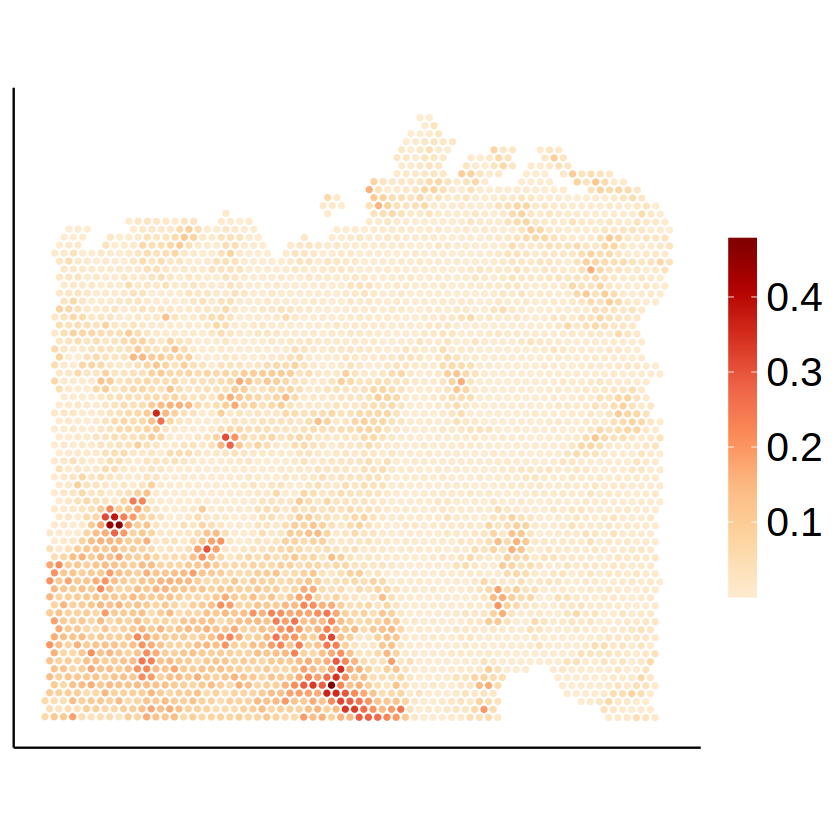

In [6]:
for (celltype in celltypes_tme) {
    p <- mcubePlotPropCellType(
        proportions_RCTD, as.matrix(myRCTD@spatialRNA@coords), celltype
    ) + labs(title = NULL, x = NULL, y = NULL) +
        guides(color = guide_colorbar(barheight = 15)) +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".pdf")
        ),
        plot = p, width = 7, height = 5
    )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".png")
        ),
        plot = p, width = 7, height = 5
    )
}
p

### Cell-type-specific SVG identification using `MCube`

In [7]:
spot_names <- colnames(myRCTD@spatialRNA@counts)
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)
spot_effects_RCTD <- log(rowSums(weights_RCTD))
names(spot_effects_RCTD) <- rownames(weights_RCTD)

In [8]:
# mcube_object <- createMCube(
#     counts = t(as.matrix(myRCTD@originalSpatialRNA@counts[, spot_names])),
#     coordinates = as.matrix(myRCTD@spatialRNA@coords),
#     proportions = proportions_RCTD,
#     library_sizes = myRCTD@spatialRNA@nUMI,
#     reference = t(myRCTD@cell_type_info$info[[1]]),
#     used_for_deconvolution = rownames(myRCTD@spatialRNA@counts),
#     spot_effects = spot_effects_RCTD,
#     celltype_threshold = 50
# )
# mcube_object <- mcubeFitNull(
#     mcube_object,
#     num_workers = 36, num_threads = 1
# )
# mcube_object <- mcubeTest(
#     mcube_object,
#     num_workers = 36, num_threads = 1, shared_memory = TRUE
# )

# saveRDS(
#     mcube_object,
#     file = file.path(
#         RESULT_PATH, "Visium",
#         paste0("mcube", ".rds")
#     )
# )

In [9]:
mcube_object <- readRDS(
    file.path(
        RESULT_PATH, tech,
        paste0("mcube", ".rds")
    )
)

#### SPP1 in Macrophage

In [10]:
celltype <- "Macrophage"
gene <- "SPP1"
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SPP1,2.313769e-13,1.129061e-60,8.640312e-56,2.370429e-06,5.905008e-11,1.129061e-60


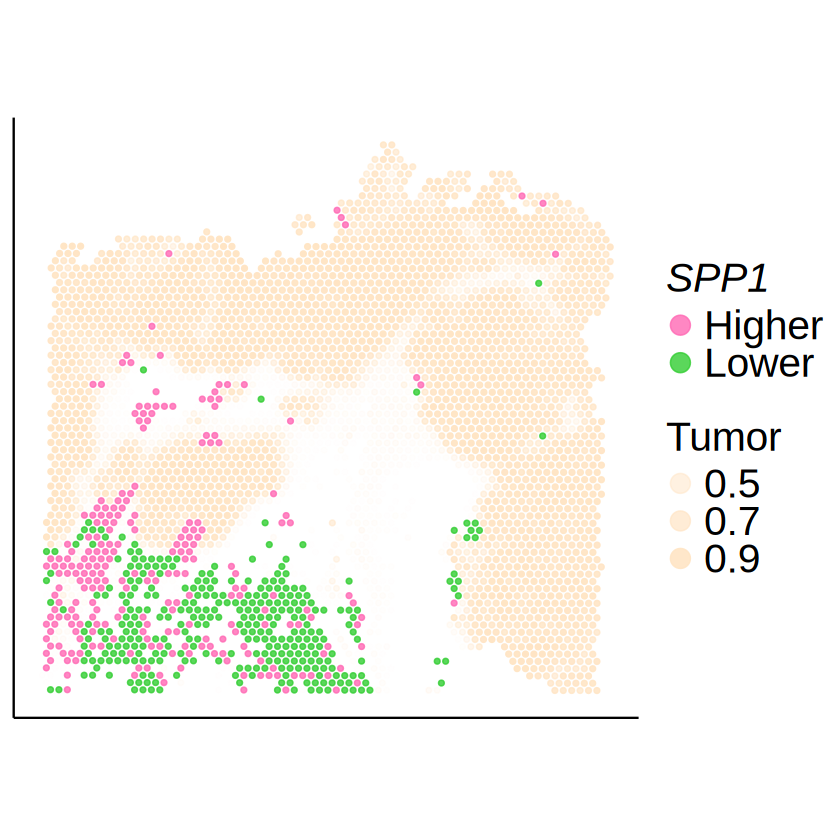

In [11]:
null_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 1
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 1, alpha = 0.8
    ) +
    scale_color_manual(
      name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(order = 1, override.aes = list(size = 5)),
        alpha = guide_legend(order = 2, override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 24),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
p

#### MMP11 in CAF

In [12]:
celltype <- "CAF"
gene <- "MMP11"
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MMP11,2.434843e-27,3.495729e-136,2.424947e-125,2.446646e-19,7.566108e-29,3.495729e-136


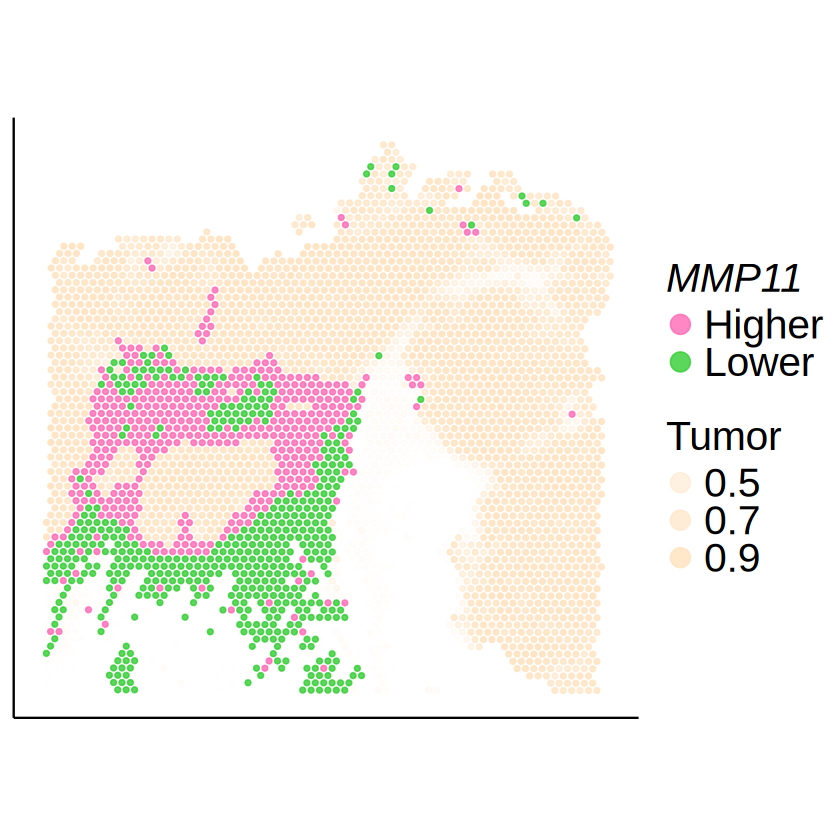

In [13]:
null_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 1
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 1, alpha = 0.8
    ) +
    scale_color_manual(
      name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(order = 1, override.aes = list(size = 5)),
        alpha = guide_legend(order = 2, override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 24),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
p

## 10x Visium HD

In [14]:
tech <- "VisiumHD"

### Cell type deconvolution using `RCTD`

In [15]:
myRCTD <- readRDS(file.path(RESULT_PATH, tech, "myRCTD_16um.rds"))
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)

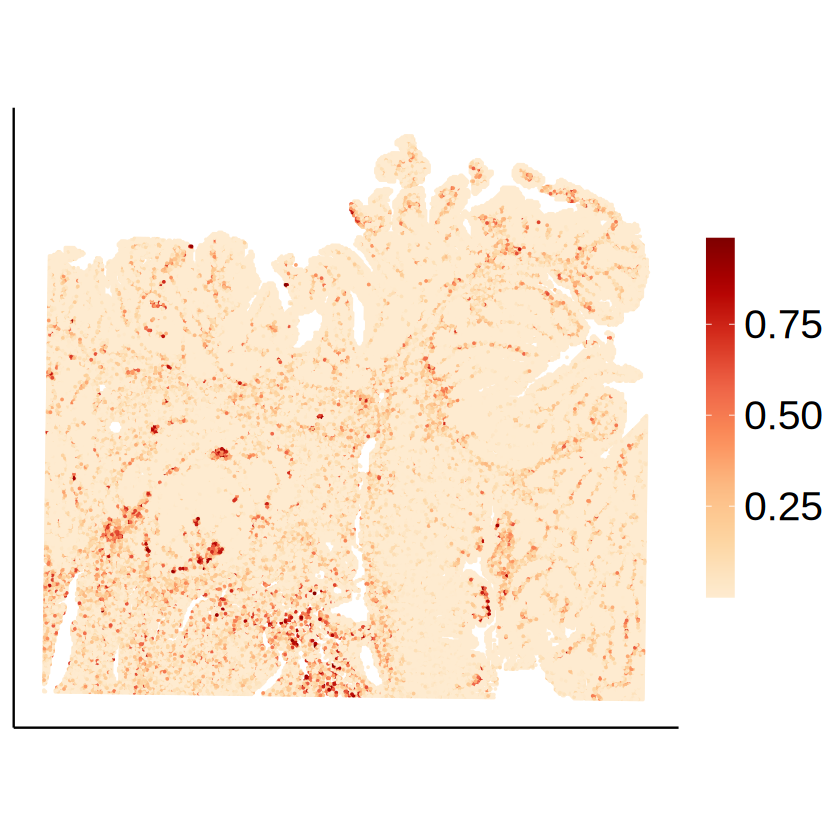

In [16]:
for (celltype in celltypes_tme) {
    p <- mcubePlotPropCellType(
        proportions_RCTD, as.matrix(myRCTD@spatialRNA@coords),
        celltype,
        spot_size = 0.01
    ) + labs(title = NULL, x = NULL, y = NULL) +
        guides(color = guide_colorbar(barheight = 15)) +
        theme(
            text = element_text(family = "Helvetica"),
            plot.title = element_text(size = 24, hjust = 0.5),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".pdf")
        ),
        plot = p, width = 7, height = 5
    )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".png")
        ),
        plot = p, width = 7, height = 5
    )
}
p

### Cell-type-specific SVG identification using `MCube`

In [17]:
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)
spot_effects_RCTD <- log(rowSums(weights_RCTD))
names(spot_effects_RCTD) <- rownames(weights_RCTD)
doublet_results_RCTD <- myRCTD@results$results_df

#### SPP1 in Macrophage

In [18]:
celltype <- "Macrophage"
gene <- "SPP1"

In [19]:
mcube_object <- readRDS(
    file.path(
        RESULT_PATH, tech,
        paste0("mcube_", celltype, ".rds")
    )
)
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SPP1,4.492731e-113,2.225074e-308,2.225074e-308,1.309304e-10,2.372605e-12,2.225074e-308


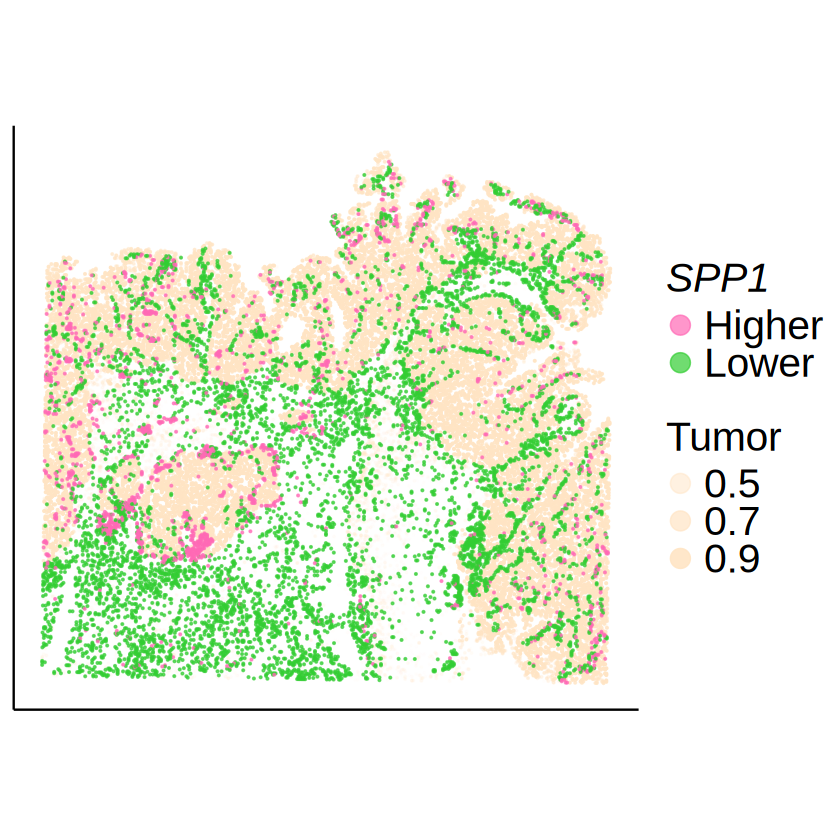

In [20]:
null_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)
tumor_df <- tumor_df[sample(1:nrow(tumor_df), 30000), ]

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 0.1
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 0.1, alpha = 0.7
    ) +
    scale_color_manual(
      name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(order = 1, override.aes = list(size = 5)),
        alpha = guide_legend(order = 2, override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 24),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
p

#### MMP11 in CAF

In [21]:
celltype <- "CAF"
gene <- "MMP11"

In [22]:
mcube_object <- readRDS(
    file.path(
        RESULT_PATH, tech,
        paste0("mcube_", celltype, ".rds")
    )
)
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MMP11,1.695596e-16,2.225074e-308,2.225074e-308,0.3893725,0.3222563,2.225074e-308


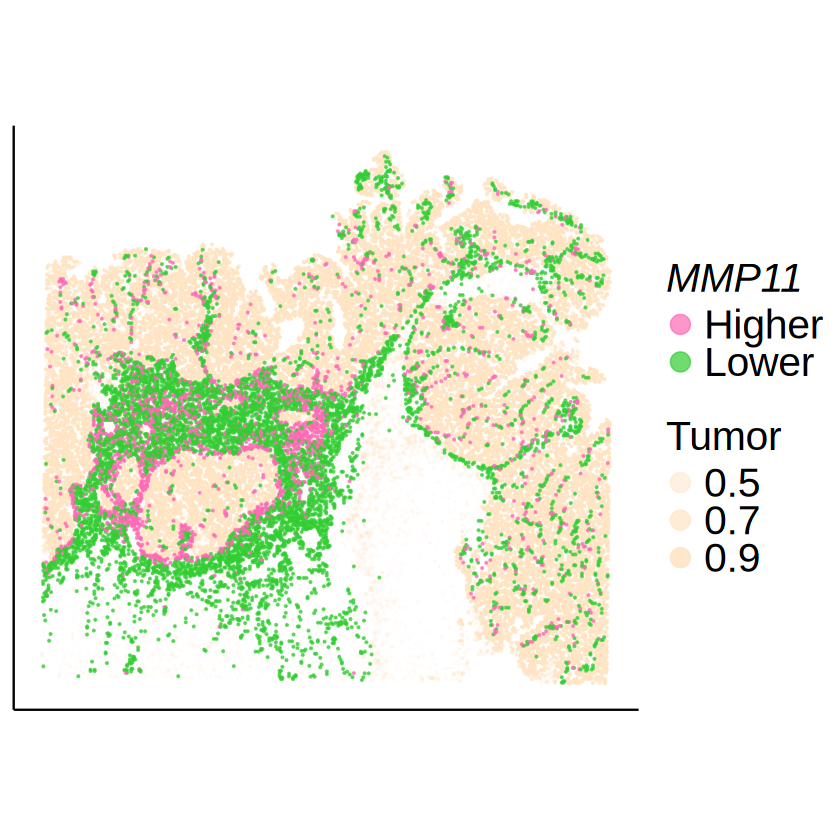

In [23]:
null_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)
tumor_df <- tumor_df[sample(1:nrow(tumor_df), 30000), ]

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 0.1
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 0.1, alpha = 0.7
    ) +
    scale_color_manual(
      name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(order = 1, override.aes = list(size = 5)),
        alpha = guide_legend(order = 2, override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 24),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
p

## 10x Xenium

In [24]:
tech <- "Xenium"

### Cell type deconvolution using `RCTD`

In [25]:
myRCTD <- readRDS(file.path(RESULT_PATH, tech, "myRCTD.rds"))
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)

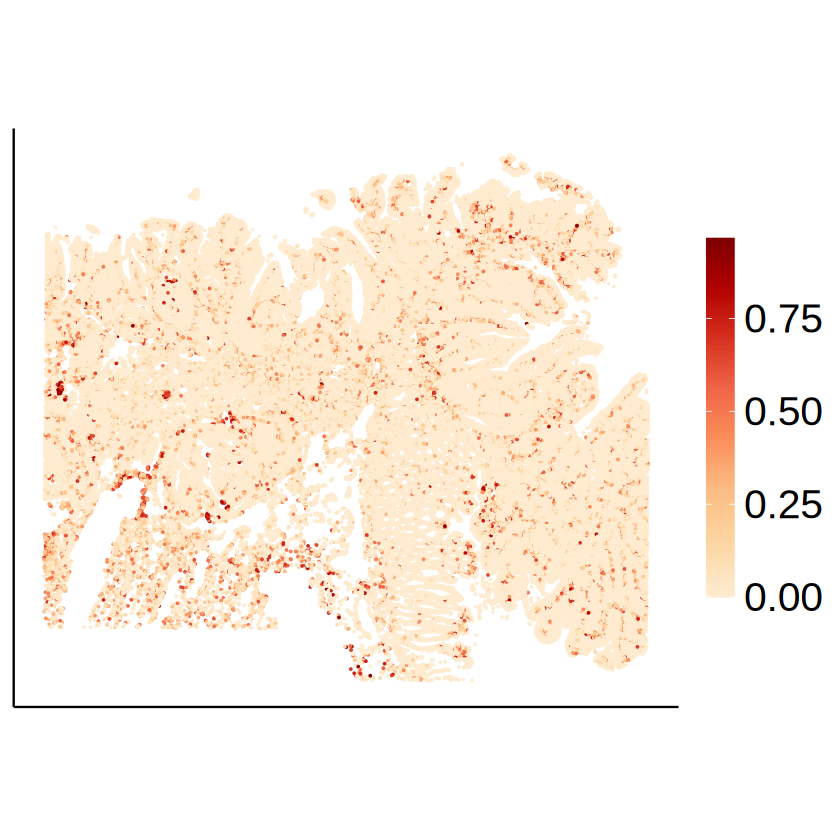

In [26]:
for (celltype in celltypes_tme) {
    p <- mcubePlotPropCellType(
        proportions_RCTD, as.matrix(myRCTD@spatialRNA@coords),
        celltype,
        spot_size = 0.01
    ) + labs(title = NULL, x = NULL, y = NULL) +
        guides(color = guide_colorbar(barheight = 15)) +
        theme(
            text = element_text(family = "Helvetica"),
            plot.title = element_text(size = 24, hjust = 0.5),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".pdf")
        ),
        plot = p, width = 7, height = 5
    )
    ggsave(
        filename = file.path(
            RESULT_PATH,
            paste0(tech, "_proportion_", celltype, ".png")
        ),
        plot = p, width = 7, height = 5
    )
}
p

### Cell-type-specific SVG identification using `MCube`

In [27]:
weights_RCTD <- as.matrix(myRCTD@results$weights)
proportions_RCTD <- weights_RCTD / rowSums(weights_RCTD)
spot_effects_RCTD <- log(rowSums(weights_RCTD))
names(spot_effects_RCTD) <- rownames(weights_RCTD)
doublet_results_RCTD <- myRCTD@results$results_df

#### SPP1 in Macrophage

In [28]:
celltype <- "Macrophage"
gene <- "SPP1"

In [29]:
mcube_object <- readRDS(
    file.path(
        RESULT_PATH, tech,
        paste0("mcube_", celltype, ".rds")
    )
)
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SPP1,6.962033e-129,2.225074e-308,2.225074e-308,0.08296263,0.02258016,2.225074e-308


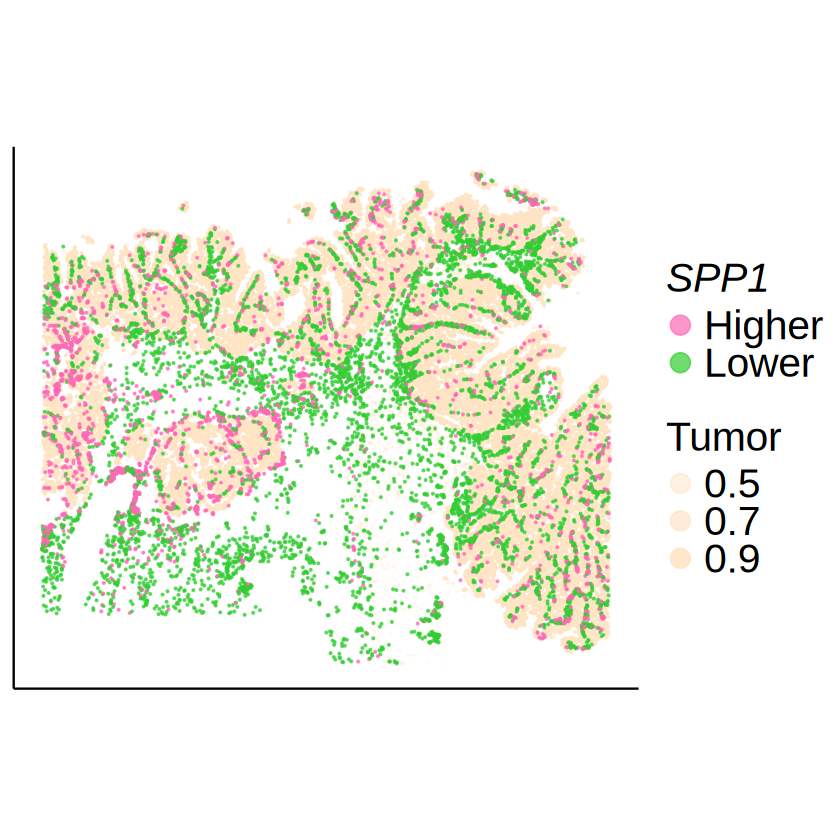

In [30]:
null_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)
tumor_df <- tumor_df[sample(1:nrow(tumor_df), 30000), ]

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 0.1
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 0.1, alpha = 0.7
    ) +
    scale_color_manual(
      name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(order = 1, override.aes = list(size = 5)),
        alpha = guide_legend(order = 2, override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 24),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
p

#### MMP11 in CAF

In [31]:
celltype <- "CAF"
gene <- "MMP11"

In [32]:
mcube_object <- readRDS(
    file.path(
        RESULT_PATH, tech,
        paste0("mcube_", celltype, ".rds")
    )
)
mcube_object@pvalues[[celltype]][gene, ]

,linear,Gaussian_1,Gaussian_2,Gaussian_transformed_1,Gaussian_transformed_2,combined_pvalue
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MMP11,0.1662907,2.225074e-308,2.225074e-308,0.008668499,0.001317351,2.225074e-308


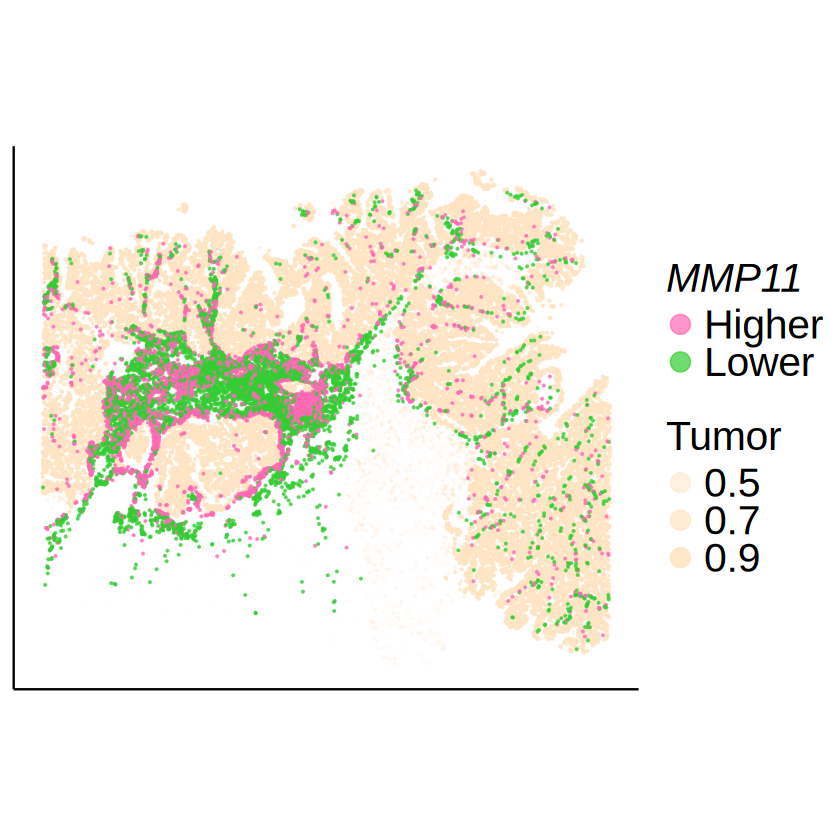

In [33]:
null_model_results <- mcube_object@null_models[[paste0(celltype, "_", gene)]]

spots_target <- null_model_results$spots
expr_level <- null_model_results$u[spots_target, celltype]
expr_level <- factor(ifelse(expr_level >= 0, "Higher", "Lower"))
target_df <- data.frame(
    x = mcube_object@coordinates[spots_target, 1],
    y = mcube_object@coordinates[spots_target, 2],
    expr_level = expr_level
)

spots_background <- setdiff(rownames(proportions_RCTD), spots_target)
tumor_df <- cbind(
    myRCTD@spatialRNA@coords[spots_background, ],
    Tumor = proportions_RCTD[spots_background, "Tumor III"]
)
tumor_df <- tumor_df[sample(1:nrow(tumor_df), 30000), ]

p <- ggplot() +
    geom_point(
        data = tumor_df, 
        aes(x = x, y = y, alpha = Tumor),
        color = "bisque", size = 0.1
    ) +
    geom_point(
        data = target_df,
        aes(x = x, y = y, color = expr_level),
        size = 0.1, alpha = 0.7
    ) +
    scale_color_manual(
      name = bquote(italic(.(gene))),
      values = c("Lower" = palettes[1], "Higher" = palettes[2])
    ) +
    scale_alpha_continuous(
        name = "Tumor",
        range = c(0, 1),
        breaks = c(0.5, 0.7, 0.9)
    ) +
    guides(
        color = guide_legend(order = 1, override.aes = list(size = 5)),
        alpha = guide_legend(order = 2, override.aes = list(size = 5))
    ) +
    scale_y_continuous(trans = "reverse") +
        coord_fixed(ratio = 1) +
        labs(title = NULL, x = NULL, y = NULL) +
        theme_classic() +
        theme(
            text = element_text(family = "Helvetica"),
            axis.text = element_blank(),
            axis.ticks = element_blank(),
            legend.title = element_text(size = 24),
            legend.text = element_text(size = 24),
            legend.position = "right"
        )
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".pdf")
    ),
    plot = p, width = 7, height = 5
)
ggsave(
    filename = file.path(
        RESULT_PATH,
        paste0(tech, "_", celltype, "_", gene, ".png")
    ),
    plot = p, width = 7, height = 5
)
p